In [ ]:
import sqlite3
import pandas as pd

con = sqlite3.connect("../01_obtener_datos/avisos_gran_concepcion.db")

df_avisos = pd.read_sql_query("SELECT * FROM avisos", con)
df_detalle = pd.read_sql_query("SELECT * FROM avisos_detalle", con)

con.close()

In [ ]:
print("Número de avisos:", df_avisos.shape[0])
print("Número de avisos con detalles:", df_detalle.shape[0])
print("% de avisos con detalles:", round((df_detalle.shape[0] / df_avisos.shape[0]) * 100, 2), "%")

Número de avisos: 1755
Número de avisos con detalles: 63
% de avisos con detalles: 3.59 %


In [ ]:
print("Null values in df_avisos:")
print(round((df_avisos.isna().sum() / df_avisos.shape[0]) * 100, 2))
print()
print("==" * 50)
print()
print("Null values in df_detalle:")
print(round((df_detalle.isna().sum() / df_detalle.shape[0]) * 100, 2))

Null values in df_avisos:
id_aviso          0.00
comuna            0.00
tipo_propiedad    0.00
operacion         0.00
titulo            0.00
precio            0.00
moneda            0.00
ubicacion         0.00
dormitorios       1.14
banos             0.40
superficie_m2     0.68
url               0.00
first_seen        0.00
dtype: float64


Null values in df_detalle:
id_aviso                    0.00
url                         0.00
descripcion                 4.76
fecha_publicacion_texto    15.87
fecha_publicacion_aprox    15.87
superficie_total_m2         1.59
superficie_util_m2          0.00
dormitorios                 0.00
banos                       0.00
estacionamientos            0.00
antiguedad_anos            26.98
amoblado                    0.00
admite_mascotas             0.00
condominio_cerrado         31.75
fecha_scrapeo               0.00
dtype: float64


In [ ]:
precios = df_avisos["precio"][df_avisos["moneda"]=="$"]

print("Top 10 precios más altos:")
precios.sort_values(ascending=False).head(10)

Top 10 precios más altos:


300     130000000.0
1211     85000000.0
52        7000000.0
1074      4000000.0
1305      4000000.0
51        3500000.0
43        3200000.0
19        3200000.0
44        3000000.0
53        3000000.0
Name: precio, dtype: float64

In [ ]:
# Eliminar los avisos con precios extremadamente altos (outliers) para un análisis más realista (>4000000)
df_avisos = df_avisos[df_avisos["precio"] <= 4000000]

<Axes: >

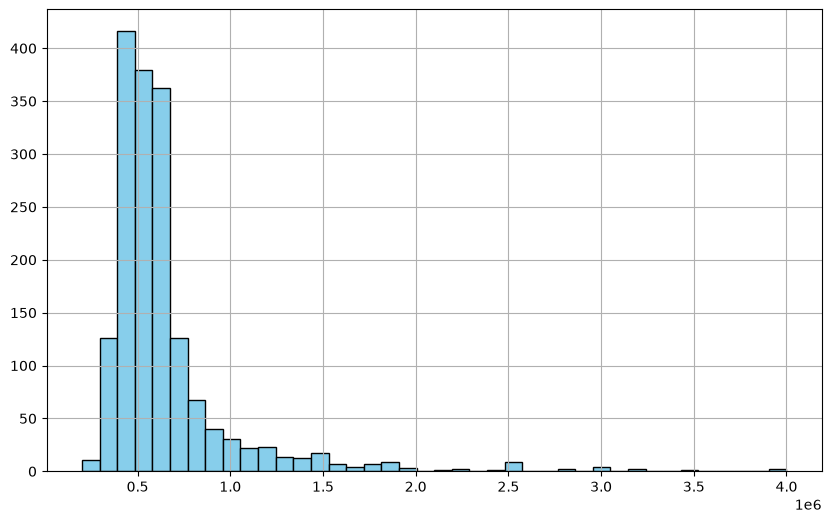

In [ ]:
# Visualización de la distribución de precios
df_avisos["precio"][df_avisos["moneda"]=="$"].hist(bins=40, figsize=(10, 6), color='skyblue', edgecolor='black')

In [ ]:
# Detalle de los arriendos mayores a 2.000.000 CLP
df_avisos[df_avisos["precio"] > 2000000]


,id_aviso,comuna,tipo_propiedad,operacion,titulo,precio,moneda,ubicacion,dormitorios,banos,superficie_m2,url,first_seen
5,MLC-1962996697,concepcion-biobio,casa,arriendo,Arriendo Centro Concepción Casa Empresas 7 Pri...,2100000.0,$,"Florida 972, Concepción, Centro De Concepción,...",4,3,210,https://portalinmobiliario.com/MLC-1962996697-...,2026-07-08
7,MLC-4061324778,concepcion-biobio,casa,arriendo,Vive Valle Las Monjas Vive Lomas De San Andres...,2500000.0,$,"Cosme Churruca, Concepción, Lomas De San André...",4,4,300,https://portalinmobiliario.com/MLC-4061324778-...,2026-07-08
8,MLC-4045568826,concepcion-biobio,casa,arriendo,Arriendo Hermosa Casa Amoblada En Lomas San An...,2500000.0,$,"Cosme Churruca, Concepción, Lomas De San André...",4,4,180,https://portalinmobiliario.com/MLC-4045568826-...,2026-07-08
13,MLC-4054603272,concepcion-biobio,casa,arriendo,"Gran Casa Familiar, A Pasos De Udec",2500000.0,$,"Tucapel 1 - 300, Concepción, Concepción",8,7,350,https://portalinmobiliario.com/MLC-4054603272-...,2026-07-08
14,MLC-4068930112,concepcion-biobio,casa,arriendo,"Casa En Arriendo En Barrio Poniente, Concepción",2800000.0,$,"Ongolmo, Concepción, Barrio Poniente, Concepción",5,3,140,https://portalinmobiliario.com/MLC-4068930112-...,2026-07-08
15,MLC-4120778906,concepcion-biobio,casa,arriendo,"Casa 6 Dormitorios,4 Baños, Uso Comercial/habi...",2400000.0,$,"Lincoyán 142, Concepción, Centro De Concepción...",6,4,220,https://portalinmobiliario.com/MLC-4120778906-...,2026-07-08
16,MLC-4118387334,concepcion-biobio,casa,arriendo,"Amplia Casa Amoblada, 6 Dormitorios, 4 Baños, ...",3000000.0,$,"Acceso Lomas De San Andrés, Concepción, Lomas ...",6,4,400,https://portalinmobiliario.com/MLC-4118387334-...,2026-07-08
19,MLC-2003322777,concepcion-biobio,casa,arriendo,Casa Amoblada De Alto Estándar Ideal Para Ejec...,3200000.0,$,"Lomas De San Andrés, Concepción",5,4,270,https://portalinmobiliario.com/MLC-2003322777-...,2026-07-08
21,MLC-4135262560,concepcion-biobio,casa,arriendo,Arriendo Amplia Casa Empresas Buena Ubicación ...,2250000.0,$,"Freire 1832, Concepción, Barrio Oriente - Las ...",8,3,280,https://portalinmobiliario.com/MLC-4135262560-...,2026-07-08
40,MLC-4027715684,concepcion-biobio,casa,arriendo,Casa En Arriendo En Lomas De San Andrés,3000000.0,$,"Acceso Lomas De San Andrés, Concepción, Lomas ...",6,6,470,https://portalinmobiliario.com/MLC-4027715684-...,2026-07-08
